In [142]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Titanic Survival Analysis: Use the classic Titanic dataset on Kaggle to perform Exploratory Data Analysis (EDA). Clean data with Pandas, calculate survival rates by class using NumPy, and visualize demographic trends with Seaborn.

In [143]:
sns.get_dataset_names()
Titanic_data=sns.load_dataset("titanic")
df=pd.DataFrame(Titanic_data)
df.head()
#df.info()#checking for null values
df.isnull().sum() #-> gives the count of null values in each column


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [144]:
print("The number of null values in the 'age' column is:", df['age'].isnull().sum())


The number of null values in the 'age' column is: 177


In [145]:
#filling the age column
print(df['age'].isnull().sum())
df['age']=df['age'].fillna(df['age'].mean()) #-> we must not use df['age'].fillna(df['age'].mean(), inplace=True), rather assign the value directly to column
df['age']=df['age'].astype(int) #or use .round(2) to round to 2 decimal places
print(df['age'].isnull().sum())
print(df['age'])


177
0
0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888    29
889    26
890    32
Name: age, Length: 891, dtype: int64


In [146]:
#now embarked data
df.head()
df['embarked']=df['embarked'].mode().iloc[0]
print(df['embarked'])

0      S
1      S
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    S
890    S
Name: embarked, Length: 891, dtype: str


In [147]:
#cabin
df=df.drop(columns=['deck'])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38,1,0,71.2833,S,First,woman,False,Cherbourg,yes,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [148]:
#categorical values
df['sex']=df['sex'].replace({'male':1,"female":0})
'''The error is happening because your class column is stored as a Categorical data type. In pandas, a 
categorical column is restricted to its predefined labels (like "First", "Second", "Third"). When you 
try to replace them with numbers (1, 2, 3), pandas blocks it because those numbers aren't in the allowed
"categories" list.'''#we can use astype(object) for instant working or do it correctly
df['class']=df['class'].cat.rename_categories({"First": 1, "Second": 2, "Third": 3})
df.drop(columns=['who'])
df['class'].value_counts()


class
3    491
1    216
2    184
Name: count, dtype: int64

In [149]:
#calculation of survival rates
print(f"based on passanger class, the survival rates are {df.groupby('pclass')['survived'].mean()*100}")

print(f"based on gender, the survival rates are {df.groupby('sex')['survived'].mean()*100}")

max_age = int(df['age'].max())
bins = list(range(0, max_age + 11, 10))
df['age_group'] = pd.cut(df['age'], bins=bins)

print(f"based on age group, the survival rates are {df.groupby('age_group')['survived'].mean()*100}")

print(f"based on gender, age and alone, the survival rates are {df.groupby(["sex","alone"])['survived'].mean()*100}")

based on passanger class, the survival rates are pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64
based on gender, the survival rates are sex
0    74.203822
1    18.890815
Name: survived, dtype: float64
based on age group, the survival rates are age_group
(0, 10]     54.385965
(10, 20]    37.931034
(20, 30]    33.333333
(30, 40]    44.516129
(40, 50]    39.285714
(50, 60]    40.476190
(60, 70]    22.222222
(70, 80]    25.000000
Name: survived, dtype: float64
based on gender, age and alone, the survival rates are sex  alone
0    False    71.276596
     True     78.571429
1    False    27.108434
     True     15.571776
Name: survived, dtype: float64


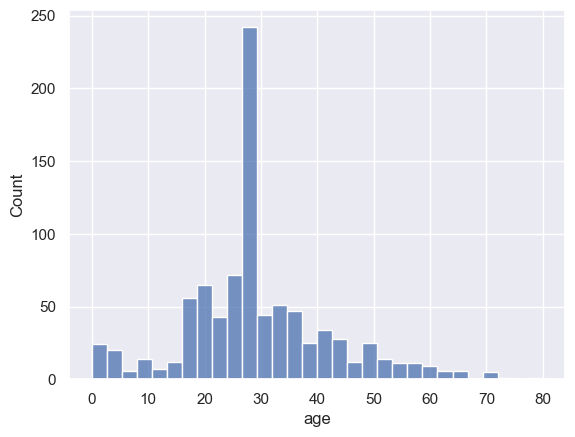

In [152]:
#Distribution plots
sns.histplot(df["age"])
plt.show()

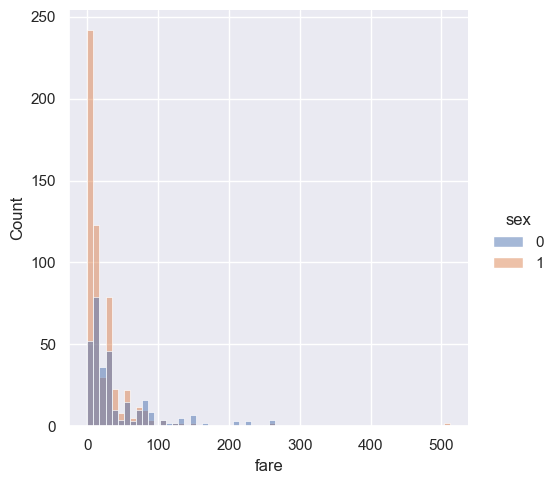

In [161]:
sns.displot(df,x='fare', hue="sex")
plt.show()

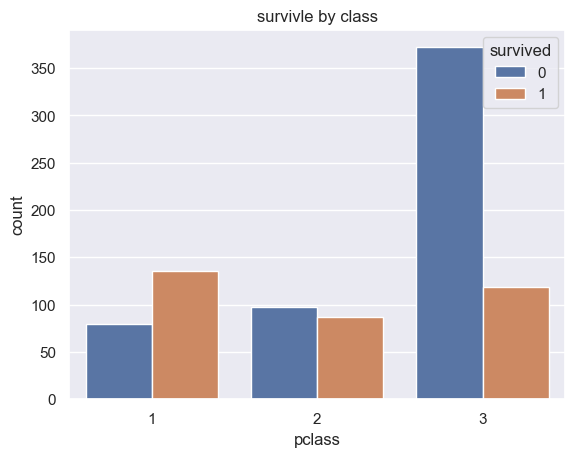

In [171]:
#count_plots
sns.countplot(df,x="pclass", hue="survived")
plt.title("survivle by class")
plt.show()

<Axes: xlabel='sex', ylabel='count'>

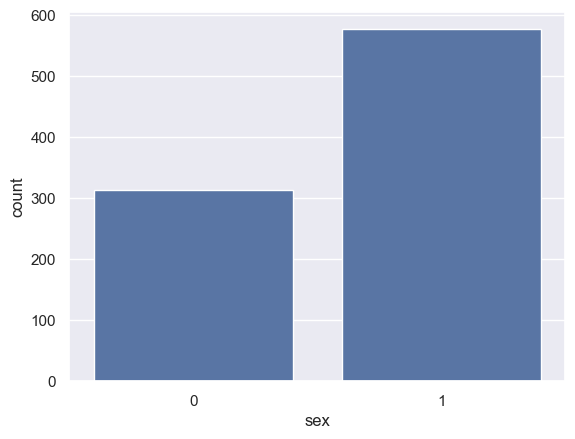

In [173]:
sns.countplot(data=df,x="sex")

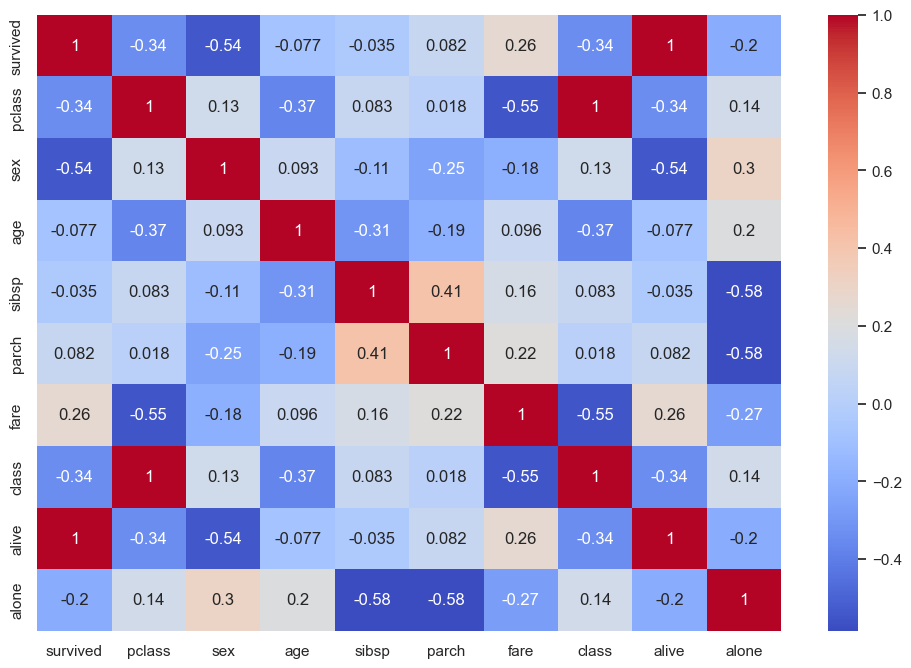

In [177]:
titanic_data=sns.load_dataset('titanic')
titanic_data.sex= titanic_data.sex.apply(lambda x: 1 if x == 'male' else 0)
titanic_data.alive= titanic_data.alive.apply(lambda x: 1 if x == 'yes' else 0)
titanic_data.alone=titanic_data.alone.apply(lambda x: 1 if x else 0)

titanic_data['class']=titanic_data['class'].apply(lambda x: 1 if x == 'First' else (2 if x == 'Second' else 3))
titanic_data=titanic_data.drop(['who','embark_town','deck', 'embarked', 'adult_male'], axis=1)

titanic_data.corr()#to find correlation between variables
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(titanic_data.corr(), annot=True, cmap='coolwarm') #annot is used to show the correlation values on the heatmap
plt.show()

learning
titanic_data.sex = titanic_data.sex.apply(lambda x: 1 if x == 'male' else 0)   -> is slow for pandas, as
it tries to apply 1 logic to every row(runs in every row). 

the below usage is good and acceptable, as it used replace that is in pandas
df['sex'] = df['sex'].replace({'male': 1, 'female': 0})

industry ml engineers approach
df['sex'] = df['sex'].map({'male': 1, 'female': 0})


World Happiness Report Analysis: Explore the World Happiness Report to see how GDP, social support, and life expectancy correlate with happiness. Use heatmap correlations in Seaborn to find the strongest drivers.
COVID-19 Data Tracker: Build a dashboard visualizing global infection rates, recoveries, and deaths. Practice using .groupby() in Pandas to summarize data by country and date.
Netflix Data Exploration: Analyze your own or public Netflix viewing history. Use Seaborn to visualize which genres you watch most or how your viewing habits change by month.
Retail Sales Analysis: Work with transaction data to identify top-performing product categories. Use bar charts in Matplotlib to compare total sales and NumPy for price elasticity calculations.
Weather Data Pattern Finder: Analyze historical weather CSVs to find seasonal patterns in temperature or rainfall. Create violin plots or line charts to show yearly anomalies.
Student Gradebook Management: Create a system that merges student rosters with grades. Calculate final averages with NumPy and use Seaborn's boxplots to see the distribution of scores across different classes.
Olympics Performance History: Download historical Olympic data and track medal counts by country over time. This is great for practicing Pandas merging and multi-line plotting in Matplotlib.
Human Activity Recognition (Basic): Use sensor data from smartphones to classify activities like walking or sitting. Focus on data preprocessing—scaling and normalizing numerical values using NumPy before visualization.